In [ ]:
#Iris Prediction using MLP

  #  1. Check the dataset for missing values and handle, if any.

  #  2. Display input and output features of the dataset.

  #  3. Encode output attribute using one hot encoder.

  #  4. Shuffle the dataset and then count and display number of tuples in each class.

  #  5. Normalize input attributes using standard scalar.

  #  6. Split dataset into training/validation/test sets in 70:15:15 ratio.

  #  7. Construct an MLP with configuration 4x32x16x8x3.
  #Use Adam optimizer and appropriate activation functions and train the model.

  #  8. Predict species of Iris flower for test data and display confusion matrix,
  # weighted avg. accuracy, macro & micro recall, macro & micro precision
  # and macro and micro F1-score

In [ ]:
import pandas as pd

# Getting the CSV file from the drive
from google.colab import drive
drive.mount('/content/drive')

# Update this path to match where your file is in your Drive
file_path = '/content/drive/My Drive/Colab Notebooks/Yujan_NN/NN_Lab3/iris.csv'

# Read the CSV
df = pd.read_csv(file_path)

# Show the first 5 rows to understand the structure of the data
print(df.head())

Mounted at /content/drive
   SepalLength  SepalWidth  PetalLength  PetalWidth     Species 
0          5.1         3.5          1.4         0.2  Iris-setosa
1          4.9         3.0          1.4         0.2  Iris-setosa
2          4.7         3.2          1.3         0.2  Iris-setosa
3          4.6         3.1          1.5         0.2  Iris-setosa
4          5.0         3.6          1.4         0.2  Iris-setosa


In [ ]:
#  1. Check the dataset for missing values and handle, if any.

# Check for missing values
print("Missing values:\n", df.isnull().sum())


#  2. Display input and output features of the dataset.
print("\nTotal colunms")
print(list(df.columns))

# Output Label
output_label = 'Species '

# Input features (everything except the 'species' column)
X = df.drop(output_label, axis=1)

# Output labels (just the 'species' column)
y = df[output_label]

print("Input Features (X):\n", list(X))
print("Output Label (y):", output_label)

# # Shuffle the dataset
# df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# # Count and display number of tuples in output class
# class_counts = df_shuffled['Species '].value_counts()
# print("\nNumber of tuples in each class after shuffling:")
# print(class_counts)
# print("Shuffled Dataset:\n", df_shuffled)


Missing values:
 SepalLength    0
SepalWidth     0
PetalLength    0
PetalWidth     0
Species        0
dtype: int64

Total colunms
['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species ']
Input Features (X):
 ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']
Output Label (y): Species 


In [ ]:
 #  3. Encode output attribute using one hot encoder.

from sklearn.preprocessing import OneHotEncoder

# Create the encoder
encoder = OneHotEncoder(sparse_output=False)

# Reshape y and encode it
y_encoded = encoder.fit_transform(y.values.reshape(-1, 1))

# Get the mapping of which column represents which category
print("\nCategory mapping:")
categories = encoder.categories_[0]  # Get the list of categories
for i, category in enumerate(categories):
    print(f"Column {i} represents: {category}")

# Example
# [1. 0. 0.]  # This is setosa
# [0. 1. 0.]  # This is versicolor
# [0. 0. 1.]  # This is virginica

# See what the encoded output looks like
print("One-hot encoded output:")
print(y_encoded[:5])  # Show first 5 rows



Category mapping:
Column 0 represents: Iris-setosa
Column 1 represents: Iris-versicolor
Column 2 represents: Iris-virginica
One-hot encoded output:
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [ ]:
#  4. Shuffle the dataset and then count and display number of tuples in each class.

from sklearn.utils import shuffle
import numpy as np

# Shuffle the dataset
X, y_encoded = shuffle(X, y_encoded, random_state=42)

# Convert one-hot encoded y back to class numbers for counting
y_classes = np.argmax(y_encoded, axis=1)

# Count and display the number of samples in each class
print("Number of samples in each class:")
print(pd.Series(y_classes).value_counts())


Number of samples in each class:
1    50
0    50
2    50
Name: count, dtype: int64


In [ ]:
#  5. Normalize input attributes using standard scalar.

from sklearn.preprocessing import StandardScaler

# Create the scaler and fit to X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Show first 5 rows of normalized data
print("Normalized input features(First 5 rows):")
print(X_scaled[:5])


Normalized input features:
[[ 3.10997534e-01 -5.87763531e-01  5.35295827e-01  1.75297293e-03]
 [-1.73673948e-01  1.72626612e+00 -1.17067529e+00 -1.18150376e+00]
 [ 2.24968346e+00 -1.05056946e+00  1.78634131e+00  1.44795564e+00]
 [ 1.89829664e-01 -3.56360566e-01  4.21564419e-01  3.96171883e-01]
 [ 1.15917263e+00 -5.87763531e-01  5.92161531e-01  2.64698913e-01]]


In [ ]:
#  6. Split dataset into training/validation/test sets in 70:15:15 ratio.

from sklearn.model_selection import train_test_split

# First, split into 85% train+val and 15% test
# X_temp, y_temp: 85% of the data → used later for training and validation.
# X_test, y_test: 15% of the data → saved for final model evaluation.
# test_size=0.15: means 15% goes into the test set.
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y_encoded, test_size=0.15, random_state=42)

# Now splitting the 85% into 70% train and 15% val
# 70/85 ≈ 0.8235 - train
# 15/85 ≈ 0.1765 - validation
# X_train, y_train: ~70% of total → for training
# X_val, y_val: ~15% of total → for validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

# Print shapes to verify the split
# X_train.shape shows how many rows and features are in the training set.
# eg: (104, 4) means 104 samples with 4 features each.
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)


Training set shape: (104, 4)
Validation set shape: (23, 4)
Test set shape: (23, 4)


In [ ]:
#  7. Construct an MLP with configuration 4x32x16x8x3.
# Use Adam optimizer and appropriate activation functions and train the model.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build the model
model = Sequential([
    Dense(32, input_shape=(4,), activation='relu'),  # input layer (4 features) → 32 neurons
    Dense(16, activation='relu'),                    # hidden layer → 16 neurons
    Dense(8, activation='relu'),                     # hidden layer → 8 neurons
    Dense(3, activation='softmax')                   # output layer → 3 neurons (3 flower types)
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # because it's multi-class classification
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5284 - loss: 1.0544 - val_accuracy: 0.7826 - val_loss: 0.9503
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7987 - loss: 0.9316 - val_accuracy: 0.7826 - val_loss: 0.8480
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7946 - loss: 0.8238 - val_accuracy: 0.7391 - val_loss: 0.7669
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8472 - loss: 0.7214 - val_accuracy: 0.7391 - val_loss: 0.6974
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7876 - loss: 0.6521 - val_accuracy: 0.7826 - val_loss: 0.6329
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8535 - loss: 0.5469 - val_accuracy: 0.7826 - val_loss: 0.5711
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8362 - loss: 0.5425 - val_accuracy: 0.7826 - val_loss: 0.5184
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8539 - loss: 0.4535 - val_accuracy: 0.7826 - val_loss: 0.4738


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step


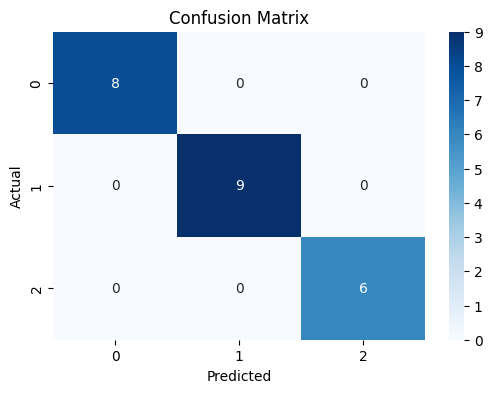

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa     1.0000    1.0000    1.0000         8
Iris-versicolor     1.0000    1.0000    1.0000         9
 Iris-virginica     1.0000    1.0000    1.0000         6

       accuracy                         1.0000        23
      macro avg     1.0000    1.0000    1.0000        23
   weighted avg     1.0000    1.0000    1.0000        23



In [ ]:
#  8. Predict species of Iris flower for test data and display confusion matrix,
# weighted avg. accuracy, macro & micro recall, macro & micro precision
# and macro and micro F1-score

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict probabilities for test data
y_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report (includes precision, recall, f1-score)
print("Classification Report:")
print(classification_report(y_true, y_pred, digits=4, target_names=encoder.categories_[0]))


In [ ]:
# Predicting a input sample
# sample = [[5.1, 3.5, 1.4, 0.2]] # iris-setosa
# sample = [[6.2,	2.9, 4.3, 1.3]] #Iris-versicolor
sample = [[6.9,	3.2,	5.7,	2.3]] #Iris-verginica

# Normalize
sample_scaled = scaler.transform(sample)

# Predict
# The model outputs probabilities for each class (setosa, versicolor, virginica)
prediction = model.predict(sample_scaled, verbose=0)  # Output might look like: [[0.01, 0.03, 0.96]]

# np.argmax returns the index of the highest value in the prediction array
# For example, if prediction = [0.01, 0.03, 0.96], np.argmax() returns 2
predicted_class = np.argmax(prediction, axis=1)

# encoder.categories_[0] contains the list of class names like: ['setosa', 'versicolor', 'virginica']
# We use the predicted index to get the matching label name
predicted_label = encoder.categories_[0][predicted_class[0]]

print("Predicted Iris species:", predicted_label)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Iris species: Iris-virginica


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
